# 📱 SMS Spam Detection Using NLP & Machine Learning

## 1. Introduction

SMS is one of the most common forms of digital communication. However, users frequently receive unwanted messages such as advertisements, fraudulent offers, fake rewards, and suspicious links.

In this project, we will develop a **Machine Learning model that can automatically classify an SMS message as either Spam or Ham (legitimate)**.

For example:

- **Spam:** `Congratulations! You have won a free prize. Click here to claim.`
- **Ham:** `Hey, I'll reach college at 10. See you there.`

This is a **Text Classification problem**, where the model learns patterns from previously labeled messages and uses those patterns to classify new messages.

---

## 2. Dataset Source

For this project, we are using the **SMS Spam Collection** dataset from the **UCI Machine Learning Repository**.

- **Dataset:** SMS Spam Collection
- **Source:** UCI Machine Learning Repository
- **Dataset Link:** https://archive.ics.uci.edu/dataset/228/sms+spam+collection
- **Total Messages:** 5,574

The dataset contains **5,574 SMS messages** collected from multiple sources.

Each message belongs to one of two categories:

| Label | Meaning |
|---|---|
| `ham` | Legitimate / non-spam message |
| `spam` | Unwanted or spam message |

---
## 3. Problem Statement

The objective of this project is to develop a **Machine Learning system capable of automatically identifying whether a given SMS message is Spam or Ham**.

The model will learn patterns from existing labeled messages and use those patterns to classify previously unseen messages.

### Example

**Input:**

> "You have won ₹50,000! Click this link to claim your prize."

**Prediction:**

> 🚨 **SPAM**

---

## 4. Role of NLP

Machine Learning algorithms cannot directly understand raw text.

For example:

> "Congratulations! You won a prize."

must first be converted into a **numerical representation** that a Machine Learning algorithm can process.

This is where **Natural Language Processing (NLP)** is used.

Our overall pipeline will be:

```text
SMS Message
     ↓
Text Preprocessing
     ↓
NLP / Feature Extraction
     ↓
Numerical Features
     ↓
Machine Learning Model
     ↓
Spam / Ham


# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

 ## 1. Importing Libraries

| Library | Alias | Purpose |
|---|---|---|
| **Pandas** | `pd` | Used for loading, manipulating, cleaning, and analyzing the dataset. |
| **NumPy** | `np` | Used for numerical operations and working with arrays and numerical data. |
| **Matplotlib** | `plt` | Used to create basic data visualizations such as graphs and charts. |
| **Seaborn** | `sns` | Used to create attractive and statistical data visualizations. |
| **NLTK** | — | Used for Natural Language Processing (NLP), such as text preprocessing and analysis. |


## 2. Data Importing and Initial Checking

In this step, we will:

- Load the SMS Spam Collection dataset.
- Assign appropriate column names.
- Check the shape of the dataset.
- Examine the first few records.
- Check the data types.
- Identify missing values.
- Check the distribution of Spam and Ham messages.

In [2]:
file_path = r"C:\Users\ASUS\Desktop\SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

| Parameter                    | Purpose                                                          |
| ---------------------------- | ---------------------------------------------------------------- |
| `file_path`                  | Stores the location of our dataset                               |
| `sep="\t"`                   | Tells Pandas that the values are separated by tabs               |
| `header=None`                | Tells Pandas that the original file doesn't contain column names |
| `names=["label", "message"]` | Gives meaningful names to our two columns                        |


In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.tail()

,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [6]:
df.sample(5)

,label,message
198,ham,is your hamster dead? Hey so tmr i meet you at...
4433,ham,Dont think you need yellow card for uk travel....
2134,ham,Spoke with uncle john today. He strongly feels...
3824,ham,Please protect yourself from e-threats. SIB ne...
2395,ham,I don't run away frm u... I walk slowly &amp; ...


In [7]:
df.shape

(5572, 2)

In [8]:
df.columns

Index(['label', 'message'], dtype='object')

In [11]:
# Checking the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
# Checking null values
df.isnull().sum()

label      0
message    0
dtype: int64

In [12]:
# Checking duplicate records
df.duplicated().sum()

np.int64(403)

In [15]:
# Checking the percentage of duplicate records
(df.duplicated().sum() / len(df)) * 100

np.float64(7.232591529073941)

In [16]:
# Checking the distribution of target classes
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [17]:
# Checking the data types of columns
df.dtypes

label      object
message    object
dtype: object

### Checking Labels of Duplicate Records

Before removing duplicate records, we need to determine how they are distributed across the **Ham** and **Spam** classes.

This is important because the dataset is already **imbalanced**, with significantly more Ham messages than Spam messages. Checking the labels of duplicate records will help us understand whether removing duplicates could disproportionately affect one of the classes.

In [18]:
# Checking the labels of duplicate records
df[df.duplicated(keep=False)]["label"].value_counts()

label
ham     503
spam    181
Name: count, dtype: int64

### Inspecting Duplicate Records

Since duplicate records form a significant portion of the dataset, especially within the **Spam** class, we should inspect the actual duplicated messages before deciding whether to remove them.

This will help us determine whether the duplicates are **exactly repeated messages with the same labels** or whether there are any cases where the **same message appears with different labels**.

In [19]:
# Displaying duplicate records along with their labels and messages
df[df.duplicated(keep=False)].sort_values(by="message")

,label,message
505,spam,+123 Congratulations - in this week's competit...
2124,spam,+123 Congratulations - in this week's competit...
2344,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
...,...,...
1381,ham,i dnt wnt to tlk wid u
1412,ham,somewhere out there beneath the pale moon ligh...
4004,ham,somewhere out there beneath the pale moon ligh...
2389,ham,wiskey Brandy Rum Gin Beer Vodka Scotch Shampa...


### Checking for Conflicting Labels

Before removing duplicate records, we need to verify whether any identical SMS messages have been assigned different labels.

If the same message appears with both **Ham** and **Spam** labels, it would indicate a label conflict that needs to be investigated before removing duplicates.

In [20]:
# Checking whether any message has more than one unique label
label_conflicts = df.groupby("message")["label"].nunique()

label_conflicts[label_conflicts > 1]

Series([], Name: label, dtype: int64)

### Checking Dataset After Removing Duplicates

Before permanently removing duplicate records, we will create a temporary dataset without duplicates and compare its size and class distribution with the original dataset.

In [21]:
# Creating a temporary dataset without duplicate records
df_no_duplicates = df.drop_duplicates()

# Checking the shape after removing duplicates
df_no_duplicates.shape

# Checking the class distribution after removing duplicates
df_no_duplicates["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

## Well after drop also we have plenty of data so let us drop it in original data alsoo


In [22]:
# Removing duplicate records
df = df.drop_duplicates().reset_index(drop=True)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the underlying patterns, distributions, and characteristics of the dataset before applying preprocessing and Machine Learning algorithms.

In this section, we will analyze the class distribution and different characteristics of the SMS messages.

| Check                             | Why do we need it?                                                                                             |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **Class distribution**            | To know whether our dataset is balanced or imbalanced.                                                         |
| **Percentage distribution**       | Raw counts tell us *how many*; percentages tell us *how imbalanced* the classes are.                           |
| **Message length**                | Spam messages may have different lengths from normal messages. Length can potentially become a useful feature. |
| **Word count**                    | Same idea, but at the word level. A spam message might contain significantly more/fewer words.                 |
| **Length distribution graph**     | Instead of just seeing averages, we can see the actual spread and whether Spam/Ham have different patterns.    |
| **Word-count distribution graph** | Helps us visually compare the text complexity/size of the two classes.                                         |
| **Average statistics**            | Gives us a quick numerical comparison between Spam and Ham.                                                    |


In [23]:
# Checking the distribution of Spam and Ham messages
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [25]:
# Checking the percentage distribution of Spam and Ham messages
df["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

In [26]:
# Calculating the number of characters in each message
df["message_length"] = df["message"].apply(len)

df[["label", "message_length"]].head()


,label,message_length
0,ham,111
1,ham,29
2,spam,155
3,ham,49
4,ham,61


In [28]:
# Calculating the number of words in each message
df["word_count"] = df["message"].apply(lambda x: len(x.split()))

df[["label", "word_count"]].head()

,label,word_count
0,ham,20
1,ham,6
2,spam,28
3,ham,11
4,ham,13


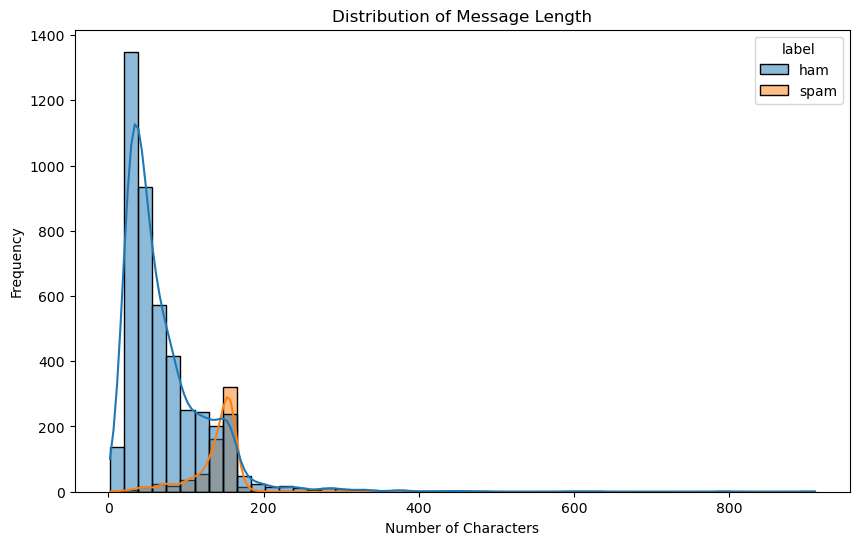

In [29]:
# Comparing message length between Spam and Ham messages
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Distribution of Message Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

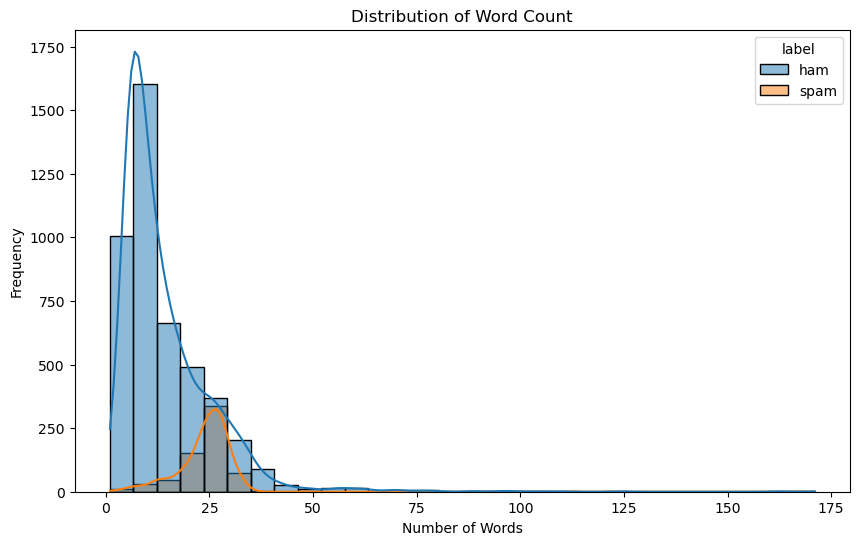

In [30]:
# Comparing word count between Spam and Ham messages
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=30,
    kde=True
)

plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [31]:
# Comparing average message statistics for Spam and Ham
df.groupby("label")[["message_length", "word_count"]].mean()

,message_length,word_count
label,,
ham,70.905890,14.239814
spam,137.704441,23.739663


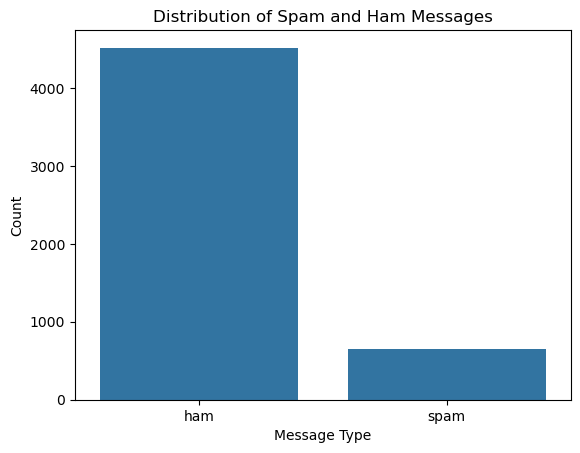

In [24]:
# Visualizing the distribution of Spam and Ham messages
sns.countplot(x="label", data=df)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

### EDA Observation

The analysis shows that Spam messages are considerably longer than Ham messages on average. Spam messages contain approximately **138 characters and 24 words**, compared with approximately **71 characters and 14 words** for Ham messages.

This indicates that **message length and word count may provide useful supporting features** for distinguishing Spam from Ham messages. However, these features alone are not sufficient for classification, as message content and word patterns are expected to play a more significant role.

## Text-Based Exploratory Data Analysis

Since this is a text classification problem, numerical characteristics such as message length and word count are not enough to understand the dataset.

In this section, we will analyze the text content of Ham and Spam messages, identify frequently occurring words, and compare the language patterns between the two classes.

| Step | Analysis | What We Do | Why We Do It |
|---|---|---|---|
| 1 | Separate Messages | Separate Ham and Spam messages from the dataset. | To analyze the two classes independently. |
| 2 | Combine Messages | Combine all messages belonging to each class into a single text collection. | To analyze word frequencies across each class. |
| 3 | Word Frequency | Count how frequently individual words occur in Ham and Spam messages. | To identify commonly used words and possible patterns. |
| 4 | Top Ham Words | Find the most frequently occurring words in Ham messages. | To understand common language used in legitimate messages. |
| 5 | Top Spam Words | Find the most frequently occurring words in Spam messages. | To identify words and patterns commonly associated with Spam. |
| 6 | Visualization | Visualize the most frequent words using bar plots. | To make differences between Ham and Spam word patterns easier to observe. |
| 7 | Interpretation | Compare the word patterns between the two classes. | To identify potentially useful textual features for classification. |

> **Note:** This analysis is performed on the raw text. We will perform proper text preprocessing, such as removing stopwords and handling punctuation, in the next stage.

In [32]:
# Combining all Ham and Spam messages separately
ham_messages = " ".join(df[df["label"] == "ham"]["message"])
spam_messages = " ".join(df[df["label"] == "spam"]["message"])

In [35]:
from collections import Counter

# Counting the frequency of words in Ham and Spam messages
ham_words = Counter(ham_messages.lower().split())
spam_words = Counter(spam_messages.lower().split())

In [37]:
# Displaying the 20 most common words in Ham messages
ham_words.most_common(20)

[('i', 2070),
 ('you', 1610),
 ('to', 1471),
 ('the', 1054),
 ('a', 965),
 ('and', 816),
 ('u', 801),
 ('in', 730),
 ('my', 670),
 ('is', 635),
 ('me', 565),
 ('for', 476),
 ('of', 472),
 ('that', 432),
 ('have', 420),
 ('it', 419),
 ('but', 397),
 ('are', 390),
 ('so', 387),
 ('your', 378)]

In [38]:
# Displaying the 20 most common words in Spam messages
spam_words.most_common(20)

[('to', 594),
 ('a', 330),
 ('call', 298),
 ('your', 241),
 ('you', 226),
 ('for', 183),
 ('the', 181),
 ('free', 157),
 ('or', 157),
 ('2', 151),
 ('is', 138),
 ('on', 119),
 ('ur', 119),
 ('from', 118),
 ('have', 115),
 ('txt', 114),
 ('and', 104),
 ('text', 96),
 ('u', 96),
 ('mobile', 95)]

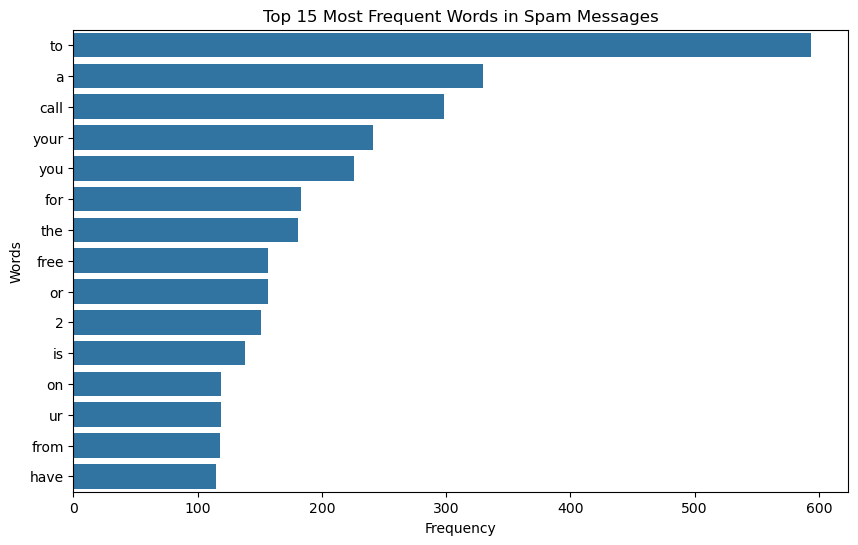

In [39]:
# Visualizing the most common words in Spam messages
spam_common = dict(spam_words.most_common(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(spam_common.values()), y=list(spam_common.keys()))

plt.title("Top 15 Most Frequent Words in Spam Messages")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

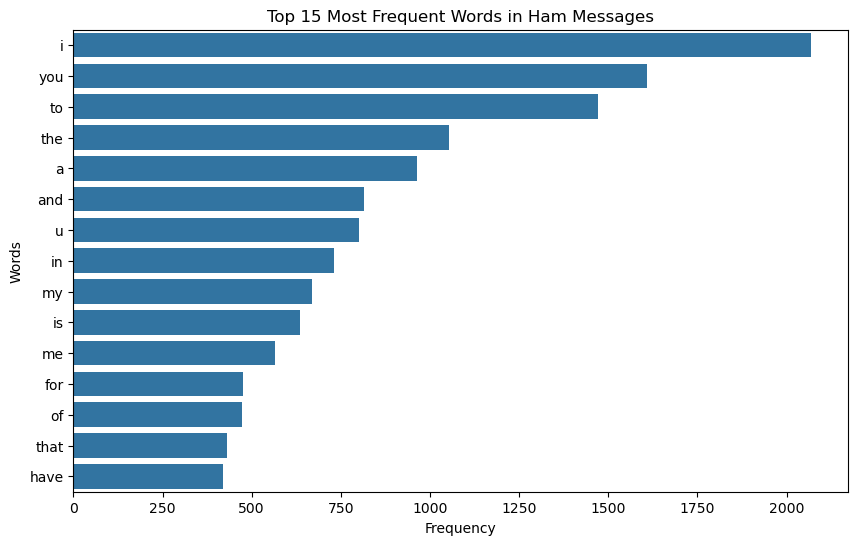

In [40]:
# Visualizing the most common words in Ham messages
ham_common = dict(ham_words.most_common(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(ham_common.values()), y=list(ham_common.keys()))

plt.title("Top 15 Most Frequent Words in Ham Messages")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

## Text Preprocessing

Raw SMS messages contain noise such as punctuation, special characters, numbers, inconsistent capitalization, and commonly occurring words that may not provide useful information for classification.

In this section, we will clean and normalize the text so that it can be effectively converted into numerical features for Machine Learning.

In [41]:
# Converting all messages to lowercase
df["message"] = df["message"].str.lower()

In [42]:
import string

# Removing punctuation from the messages
df["message"] = df["message"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [43]:
# Removing numerical characters from the messages
df["message"] = df["message"].str.replace(r"\d+", "", regex=True)

In [44]:
# Removing extra spaces from the messages
df["message"] = df["message"].str.strip().str.replace(r"\s+", " ", regex=True)

In [45]:
# Removing extra spaces from the messages
df["message"] = df["message"].str.strip().str.replace(r"\s+", " ", regex=True)

| Step | Operation | Code / Method | What It Does | Why We Do It |
|---|---|---|---|---|
| 1 | **Convert to Lowercase** | `.str.lower()` | Converts all text to lowercase. | Treats words like `FREE`, `Free`, and `free` as the same word. |
| 2 | **Remove Punctuation** | `string.punctuation` + `translate()` | Removes characters such as `!`, `.`, `,`, `?`, and `:`. | Reduces unnecessary variations caused by punctuation. |
| 3 | **Remove Numbers** | `.str.replace(r"\d+", "", regex=True)` | Removes numerical characters from the messages. | Reduces noise from numbers that may not contribute to basic word-based analysis. |
| 4 | **Remove Extra Whitespace** | `.str.strip()` + `.str.replace(r"\s+", " ", regex=True)` | Removes leading/trailing spaces and converts multiple spaces into a single space. | Keeps the text clean and consistently formatted. |
| 5 | **Check Cleaned Messages** | `df[["label", "message"]].head(10)` | Displays the first 10 cleaned messages along with their labels. | Allows us to verify that preprocessing was performed correctly. |

## Stopword Analysis

Stopwords are commonly occurring words such as `the`, `is`, `a`, `to`, and `you` that often contribute little to the meaning of a text classification task.

Before removing them, we will examine the available English stopwords and determine how they may affect our SMS classification problem.

In [46]:
# Downloading the NLTK stopwords dataset
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [47]:
from nltk.corpus import stopwords

# Loading the English stopwords
stop_words = set(stopwords.words("english"))

# Displaying the number of available stopwords
len(stop_words)

198

In [48]:
# Displaying the first 20 English stopwords
list(stop_words)[:20]

['didn',
 'has',
 'further',
 'in',
 'not',
 "i'll",
 'for',
 "i'm",
 'doesn',
 "doesn't",
 'isn',
 'but',
 'me',
 'be',
 'here',
 'these',
 "wouldn't",
 "couldn't",
 "they're",
 "weren't"]

In [49]:
# Checking how many words in our dataset are stopwords
all_words = " ".join(df["message"]).split()

stopword_count = sum(word in stop_words for word in all_words)
total_words = len(all_words)

print("Total Words:", total_words)
print("Stopwords:", stopword_count)
print("Stopword Percentage:", (stopword_count / total_words) * 100)

Total Words: 76652
Stopwords: 30712
Stopword Percentage: 40.06679538694359


In [50]:
# Displaying common stopwords found in the dataset
word_frequency = Counter(all_words)

common_stopwords = {
    word: count
    for word, count in word_frequency.most_common()
    if word in stop_words
}

list(common_stopwords.items())[:20]

[('i', 2132),
 ('to', 2078),
 ('you', 2036),
 ('a', 1306),
 ('the', 1240),
 ('and', 923),
 ('in', 820),
 ('is', 796),
 ('me', 743),
 ('my', 684),
 ('for', 665),
 ('your', 619),
 ('it', 574),
 ('of', 559),
 ('have', 539),
 ('that', 497),
 ('on', 492),
 ('are', 462),
 ('now', 428),
 ('so', 419)]

## Text Vectorization

Machine Learning algorithms cannot directly work with raw text. Therefore, the cleaned SMS messages need to be converted into numerical representations.

In this project, we will experiment with two common text vectorization techniques:

- **Bag of Words (BoW)** — represents text using word occurrence counts.
- **TF-IDF** — assigns weights based on the importance of words within individual messages and across the complete dataset.

Both representations will later be used with Machine Learning models and their performance will be compared.

In [51]:
from sklearn.model_selection import train_test_split

# Separating input features and target variable
X = df["message"]
y = df["label"]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Bag of Words (BoW)

Bag of Words converts each SMS message into a numerical vector based on the frequency of words in the dataset.

Each unique word becomes a feature, and the value represents how frequently that word occurs in a particular message.

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

# Creating the Bag of Words vectorizer
bow_vectorizer = CountVectorizer()

# Learning the vocabulary from training data and transforming it
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Transforming the test data using the same vocabulary
X_test_bow = bow_vectorizer.transform(X_test)

print("Training Shape:", X_train_bow.shape)
print("Testing Shape:", X_test_bow.shape)

Training Shape: (4135, 7555)
Testing Shape: (1034, 7555)


In [53]:
# Checking the number of unique words learned by BoW
print("Vocabulary Size:", len(bow_vectorizer.vocabulary_))

Vocabulary Size: 7555


In [54]:
# Displaying the first SMS and its numerical representation
print("Message:", X_train.iloc[0])
print("\nBoW Vector:")
print(X_train_bow[0].toarray())

Message: tadaaaaa i am home babe are you still up

BoW Vector:
[[0 0 0 ... 0 0 0]]


### TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF represents each word according to how important it is to a particular SMS relative to the complete collection of messages.

Words that occur frequently across many messages receive lower importance, while words that are more specific to certain messages receive higher weights.

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Creating the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Learning TF-IDF features from training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transforming the test data using the same vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (4135, 7555)
Testing Shape: (1034, 7555)


In [56]:
# Checking the number of unique words learned by TF-IDF
print("Vocabulary Size:", len(tfidf_vectorizer.vocabulary_))

Vocabulary Size: 7555


In [58]:
# Displaying some words from the BoW vocabulary
list(bow_vectorizer.vocabulary_.keys())[:20]

['tadaaaaa',
 'am',
 'home',
 'babe',
 'are',
 'you',
 'still',
 'up',
 'yup',
 'having',
 'my',
 'lunch',
 'buffet',
 'now',
 'eat',
 'already',
 'ok',
 'anyway',
 'no',
 'need']

In [59]:
# Displaying some words from the TF-IDF vocabulary
list(tfidf_vectorizer.vocabulary_.keys())[:20]

['tadaaaaa',
 'am',
 'home',
 'babe',
 'are',
 'you',
 'still',
 'up',
 'yup',
 'having',
 'my',
 'lunch',
 'buffet',
 'now',
 'eat',
 'already',
 'ok',
 'anyway',
 'no',
 'need']

In [60]:
# Comparing BoW and TF-IDF representation of the same message
sample_message = X_train.iloc[0]

print("Message:")
print(sample_message)

Message:
tadaaaaa i am home babe are you still up


In [61]:
# Displaying the BoW representation
print("BoW:")
print(X_train_bow[0].toarray())

BoW:
[[0 0 0 ... 0 0 0]]


In [62]:
# Displaying the TF-IDF representation
print("TF-IDF:")
print(X_train_tfidf[0].toarray())

TF-IDF:
[[0. 0. 0. ... 0. 0. 0.]]


### Comparing BoW and TF-IDF Representations

After converting the SMS messages into numerical features using both **Bag of Words (BoW)** and **TF-IDF**, we compared their representations for the same message.

| Technique | Representation | What the Values Mean |
|---|---|---|
| **Bag of Words** | Word-count based | Number of times a word appears in a message. |
| **TF-IDF** | Importance based | Importance of a word in a message relative to the complete dataset. |

Both techniques produced the same **7,555 features** because they learned the same vocabulary from the training data. However, the numerical values assigned to those features are different.

This comparison helps us understand how the same text can be represented differently before being provided to Machine Learning models.

## Machine Learning Models

To classify SMS messages as **Ham or Spam**, we will experiment with three supervised Machine Learning algorithms: **Multinomial Naive Bayes, Logistic Regression, and Support Vector Classifier (SVC)**.

These models are suitable for text classification because the dataset has been converted into high-dimensional numerical features using **Bag of Words and TF-IDF**.

| Model | Why We Are Using It |
|---|---|
| **Multinomial Naive Bayes** | A fast and effective baseline for text classification, especially with word-frequency based features. |
| **Logistic Regression** | A strong linear classification algorithm that works well with high-dimensional text features. |
| **SVC** | Finds an optimal decision boundary between Ham and Spam and is effective for high-dimensional feature spaces. |

### Why Linear SVC?

We will use **SVC with a linear kernel** instead of the default RBF kernel because our feature matrices contain thousands of text features and are highly sparse.

A linear decision boundary is computationally more suitable for this type of text classification problem while still providing strong classification performance.

Therefore, our models will be:

- **Multinomial Naive Bayes**
- **Logistic Regression**
- **SVC with Linear Kernel**

Each model will be trained using both **Bag of Words** and **TF-IDF**, allowing us to compare which combination performs best.

In [63]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [64]:
# Creating Machine Learning models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

In [65]:
# Training models using Bag of Words features
bow_models = {}

for name, model in models.items():
    model.fit(X_train_bow, y_train)
    bow_models[name] = model

In [66]:
# Training models using TF-IDF features
tfidf_models = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    tfidf_models[name] = model

In [67]:
# Generating predictions using BoW models
bow_predictions = {}

for name, model in bow_models.items():
    bow_predictions[name] = model.predict(X_test_bow)

# Generating predictions using TF-IDF models
tfidf_predictions = {}

for name, model in tfidf_models.items():
    tfidf_predictions[name] = model.predict(X_test_tfidf)

## Model Evaluation

After training the Machine Learning models, we will evaluate their performance on both the training and testing datasets.

Training performance will help us identify whether a model has learned the training data excessively, while testing performance will indicate how well the model generalizes to unseen SMS messages.

Since the dataset is imbalanced, Accuracy alone is not sufficient for evaluating Spam detection. Therefore, we will also use Precision, Recall, and F1-score, with Spam considered as the positive class.

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [72]:
# Evaluating all models using training and testing data

results = []

# Evaluating BoW models
for name, model in bow_models.items():
    train_pred = model.predict(X_train_bow)
    test_pred = model.predict(X_test_bow)

    results.append({
        "Vectorizer": "BoW",
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, pos_label="spam"),
        "Recall": recall_score(y_test, test_pred, pos_label="spam"),
        "F1 Score": f1_score(y_test, test_pred, pos_label="spam")
    })


# Evaluating TF-IDF models
for name, model in tfidf_models.items():
    train_pred = model.predict(X_train_tfidf)
    test_pred = model.predict(X_test_tfidf)

    results.append({
        "Vectorizer": "TF-IDF",
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, pos_label="spam"),
        "Recall": recall_score(y_test, test_pred, pos_label="spam"),
        "F1 Score": f1_score(y_test, test_pred, pos_label="spam")
    })


# Creating the final results DataFrame
results = pd.DataFrame(results)

# Resetting index to maintain proper experiment order
results.index = range(1, len(results) + 1)

# Displaying results
results

,Vectorizer,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
1,BoW,Naive Bayes,0.968561,0.961315,1.000000,0.694656,0.819820
2,BoW,Logistic Regression,0.912938,0.891683,0.541485,0.946565,0.688889
3,BoW,Linear SVM,0.956953,0.918762,0.612440,0.977099,0.752941
4,TF-IDF,Naive Bayes,0.960580,0.947776,1.000000,0.587786,0.740385
5,TF-IDF,Logistic Regression,0.969528,0.960348,0.959184,0.717557,0.820961
6,TF-IDF,Linear SVM,0.999033,0.978723,0.957983,0.870229,0.912000


## Confusion Matrix

A confusion matrix provides a detailed view of the classification results by showing how many Ham and Spam messages were correctly or incorrectly classified.

It helps us identify:

- **True Positives (TP):** Spam messages correctly classified as Spam.
- **True Negatives (TN):** Ham messages correctly classified as Ham.
- **False Positives (FP):** Ham messages incorrectly classified as Spam.
- **False Negatives (FN):** Spam messages incorrectly classified as Ham.

This allows us to understand the types of classification errors made by the selected model.

In [73]:
from sklearn.metrics import confusion_matrix

# Getting predictions from the best model
best_model = tfidf_models["Linear SVM"]

y_pred = best_model.predict(X_test_tfidf)

# Creating confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

cm

array([[898,   5],
       [ 17, 114]])

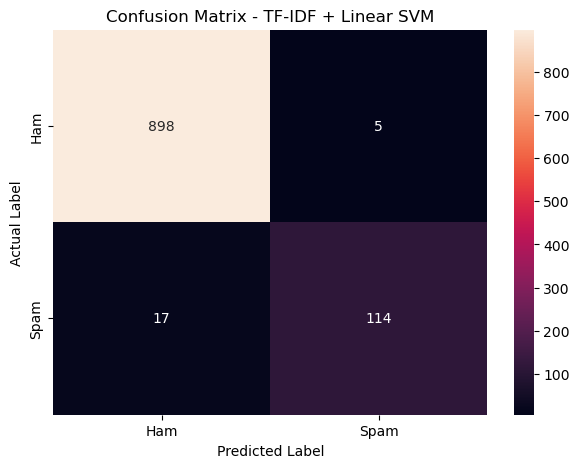

In [74]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - TF-IDF + Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [75]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    labels=["ham", "spam"]
))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.96      0.87      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



## Hyperparameter Tuning

The baseline evaluation showed that **TF-IDF with Linear SVM** achieved the best overall performance among the tested configurations.

To determine whether its performance can be further improved, hyperparameter tuning will be performed on the selected model.

The **C parameter** of Linear SVM will be varied across different values and evaluated using F1-score, with Spam considered as the positive class.

The tuned model will then be compared with the original baseline model to determine whether tuning provides a meaningful improvement.

In [86]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

# Creating an F1 scorer with Spam as the positive class
spam_f1 = make_scorer(
    f1_score,
    pos_label="spam"
)

# Defining hyperparameters
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# Creating Grid Search
grid_search = GridSearchCV(
    estimator=LinearSVC(),
    param_grid=param_grid,
    scoring=spam_f1,
    cv=5,
    n_jobs=-1
)

# Training Grid Search
grid_search.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...os_label=spam)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with h

In [87]:
# Displaying the best hyperparameter and CV score
print("Best C:", grid_search.best_params_["C"])
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best C: 10
Best Cross-Validation F1 Score: 0.9038170788874433


In [88]:
# Comparing all tested C values
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results[
    ["param_C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")


,param_C,mean_test_score,std_test_score,rank_test_score
3,10.00,0.903817,0.024579,1
4,100.00,0.894709,0.024251,2
2,1.00,0.894129,0.024017,3
1,0.10,0.811522,0.024321,4
0,0.01,0.000000,0.000000,5


In [89]:
# Getting the best tuned model
best_tuned_model = grid_search.best_estimator_

# Predicting on the unseen test data
tuned_pred = best_tuned_model.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, tuned_pred))
print("Precision:", precision_score(y_test, tuned_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, tuned_pred, pos_label="spam"))
print("F1 Score:", f1_score(y_test, tuned_pred, pos_label="spam"))

Test Accuracy: 0.97678916827853
Precision: 0.928
Recall: 0.8854961832061069
F1 Score: 0.90625


In [90]:
# Evaluating the tuned model on training data
tuned_train_pred = best_tuned_model.predict(X_train_tfidf)

print("Training Accuracy:", accuracy_score(y_train, tuned_train_pred))
print("Training F1 Score:", f1_score(y_train, tuned_train_pred, pos_label="spam"))

Training Accuracy: 1.0
Training F1 Score: 1.0


## Learning from Hyperparameter Tuning

Before performing hyperparameter tuning, I always assumed that tuning a model would automatically improve its performance.

However, this experiment showed that **hyperparameter tuning does not necessarily make a model better**.

The tuned TF-IDF + Linear SVM achieved:

- **100% Training Accuracy**
- **100% Training F1-score**
- **97.68% Testing Accuracy**
- **90.63% Testing F1-score**

In comparison, the original model achieved a higher **Test Accuracy of 97.87%** and **F1-score of 91.20%**.

This showed me that a model can perform better on the training data while performing slightly worse on unseen data. Therefore, hyperparameter tuning should not be treated as a guaranteed performance improvement. Instead, the tuned model should always be evaluated on unseen data and compared with the original baseline.

### Key Learning

> **Hyperparameter tuning is a method for finding better parameters, not a guarantee of a better model.**

In this project, the original TF-IDF + Linear SVM model performed better, so it was retained as the final model.

## Final Model Selection

After comparing multiple Machine Learning models using both Bag of Words and TF-IDF representations, **TF-IDF + Linear SVM** achieved the best overall performance.

Hyperparameter tuning was also performed, but the tuned model did not improve the performance on unseen test data. Therefore, the original TF-IDF + Linear SVM model was retained as the final model.

The final model achieved:

- **Test Accuracy:** 97.87%
- **Precision:** 95.80%
- **Recall:** 87.02%
- **F1-score:** 91.20%

We will now use this model to classify new, previously unseen SMS messages as **Ham or Spam**.

In [91]:
# Selecting the final model
final_model = tfidf_models["Linear SVM"]

In [92]:
# Function to predict whether a new SMS is Ham or Spam

def predict_sms(message):
    message = message.lower()
    message = message.translate(
        str.maketrans("", "", string.punctuation)
    )
    message = re.sub(r"\d+", "", message)
    message = re.sub(r"\s+", " ", message).strip()

    message_tfidf = tfidf_vectorizer.transform([message])

    prediction = final_model.predict(message_tfidf)[0]

    return prediction

In [93]:
import re

In [94]:
# Testing the final model with new SMS messages

messages = [
    "Congratulations! You have won a free prize. Click now to claim.",
    "Hey, are we still meeting for lunch today?",
    "URGENT! You have won 50000 rupees. Call now to claim your reward."
]

for message in messages:
    print("Message:", message)
    print("Prediction:", predict_sms(message))
    print("-" * 60)

Message: Congratulations! You have won a free prize. Click now to claim.
Prediction: spam
------------------------------------------------------------
Message: Hey, are we still meeting for lunch today?
Prediction: ham
------------------------------------------------------------
Message: URGENT! You have won 50000 rupees. Call now to claim your reward.
Prediction: spam
------------------------------------------------------------


## Error Analysis

After evaluating the final model, we will analyze the messages that were incorrectly classified.

This will help us understand the types of mistakes made by the model rather than relying only on overall performance metrics.

We will focus on two types of errors:

- **False Positives:** Actual Ham messages predicted as Spam.
- **False Negatives:** Actual Spam messages predicted as Ham.

Examining these errors can help us understand the limitations of the final model and the challenges involved in SMS Spam classification.

In [95]:
# Creating a DataFrame for test predictions
error_analysis = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred
})

error_analysis.head()

,message,actual,predicted
4940,good morning my love i go to sleep now and wis...,ham,ham
4908,and how you will do that princess,ham,ham
2358,cool ill text you when im on the way,ham,ham
1267,your right ill make the appointment right now,ham,ham
4738,aiya we discuss later lar pick ü up at is it,ham,ham


In [96]:
# Finding False Positives
false_positives = error_analysis[
    (error_analysis["actual"] == "ham") &
    (error_analysis["predicted"] == "spam")
]

print("False Positives:", len(false_positives))

false_positives

False Positives: 5


,message,actual,predicted
1262,your daily text from me – a favour this time,ham,spam
487,are you free nowcan i call now,ham,spam
4806,k k sms chat with me,ham,spam
1620,glad to see your reply,ham,spam
4416,i career tel have added u as a contact on indy...,ham,spam


In [97]:
# Finding False Negatives
false_negatives = error_analysis[
    (error_analysis["actual"] == "spam") &
    (error_analysis["predicted"] == "ham")
]

print("False Negatives:", len(false_negatives))

false_negatives

False Negatives: 17


,message,actual,predicted
521,you will recieve your tone within the next hrs...,spam,ham
2697,send a logo ur lover names joined by a heart t...,spam,ham
5139,asked mobile if chatlines inclu in free mins i...,spam,ham
1423,hi its lucy hubby at meetins all day fri i wil...,spam,ham
3949,missed call alert these numbers called but lef...,spam,ham
1830,freemsg hey u i just got of these videopic fon...,spam,ham
2303,babe u want me dont u baby im nasty and have a...,spam,ham
4499,check out choose your babe videos smsshsexnetu...,spam,ham
3890,in the simpsons movie released in july name th...,spam,ham
3332,xmas new years eve tickets are now on sale fro...,spam,ham


In [98]:
# Summarizing classification errors
print("Total Test Messages:", len(error_analysis))
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))
print("Total Errors:", len(false_positives) + len(false_negatives))

Total Test Messages: 1034
False Positives: 5
False Negatives: 17
Total Errors: 22


## Error Analysis Findings

The final model produced **22 incorrect predictions** out of 1,034 test messages:

- **5 False Positives:** Ham messages incorrectly classified as Spam.
- **17 False Negatives:** Spam messages incorrectly classified as Ham.

The False Negative analysis shows that several Spam messages use language that resembles ordinary conversational or informational SMS messages. Some promotional and service-related messages also contain uncommon vocabulary that may not have strong representation in the learned TF-IDF features.

This indicates that the model can struggle when Spam messages do not contain the common patterns or keywords frequently associated with Spam in the training data.

Overall, the error analysis demonstrates that while TF-IDF + Linear SVM performs strongly, it does not understand the semantic meaning of a message. Its predictions are primarily based on learned statistical patterns in the text.

In [100]:
import joblib

# Saving the final model
joblib.dump(final_model, "sms_spam_svm_model.pkl")


['sms_spam_svm_model.pkl']

In [101]:
# Saving the TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, "sms_spam_tfidf_vectorizer.pkl")

['sms_spam_tfidf_vectorizer.pkl']